CS524: Introduction to Optimization Lecture 41
======================================

## Michael Ferris<br> Computer Sciences Department <br> University of Wisconsin-Madison

## December 9, 2025
--------------

In [42]:
import gamspy as gp
import gamspy.math as gpm

import sys
import numpy as np
import pandas as pd

from collections import OrderedDict

In [43]:
# plotting routines

import networkx as nx
import matplotlib.pyplot as plt

def digraph_draw(G, layout, ax, node_size=4000):
    # layout selection
    if layout == "spring":
        pos = nx.spring_layout(G)
    elif layout == "kamada_kawai":
        pos = nx.kamada_kawai_layout(G)
    elif layout == "circular":
        pos = nx.circular_layout(G)
    elif layout == "shell":
        pos = nx.shell_layout(G)
    elif layout == "dot":
        pos = nx.nx_pydot.graphviz_layout(G, prog="neato")
    else:
        raise ValueError("Unknown layout")
        
    # Node size needs to be tuned depending on the data
    nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color="#aaccee", ax=ax)

    nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=20, min_target_margin=node_size/100, ax=ax)

    node_labels = {
        n: f"{n}\n{G.nodes[n]['label']}" if G.nodes[n]["label"] is not None else n
        for n in G.nodes
    }
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=10, ax=ax)

    arc_labels = {
        (i, j): G.edges[i, j]["label"]
        for i, j in G.edges
        if G.edges[i, j]["label"] is not None
    }
    
    nx.draw_networkx_edge_labels(G, pos, edge_labels=arc_labels, font_color="red", ax=ax)

def getNodeLabel(node_values, n):
    if node_values is None:
        return None
    if type(node_values) is OrderedDict:
        vals = {}
        for k,v in node_values.items():
            vals[k] = v.get(n,0)
        
        return "\n".join(f"{k}{n} = {v}" for k,v in vals.items())

    else: #catchall: we assume we have the prices
        val = node_values.get(n,0)
        return f"p{n} = {val}\n"

def getArcLabel(arc_values, src, dst):
    if arc_values is None:
        return None
        
    if type(arc_values) is OrderedDict:
        vals = {}
        for k,v in arc_values.items():
            vals[k] = v.get((src,dst),0)
        
        return "\n".join(f"{k}: {v}" for k,v in vals.items())

    else: #catchall: we assume we have the prices
        val = arc_values.get((src,dst),0)
        return f"{val}"

def gamspy_to_digraph_plot(node_set, arc_set, node_values=None, arc_values=None,
                           figsize=(6, 6), layout="shell", title=None, graphs={}):
    """
    Build and display a directed NetworkX graph in a Jupyter notebook.

    Parameters
    ----------
    node_set : gamspy.Set
        1-D GAMSPy set of nodes.

    arc_set : gamspy.Set
        2-D GAMSPy set of arcs (i, j).

    node_values : dict, optional
        Mapping node -> value to use as node label.

    arc_values : dict, optional
        Mapping (i, j) -> value to use as edge label.

    figsize : tuple
        Size of the drawn figure.

    layout : str
        One of: "spring", "kamada_kawai", "circular", "shell".
    """

    G = nx.DiGraph()

    # --- Build graph ---
    
    for n in node_set.toList():
        G.add_node(n, label=getNodeLabel(node_values, n))

    for src, dst in arc_set.toList():
        G.add_edge(src, dst, label=getArcLabel(arc_values, src, dst))

    # --- Draw ---
    nfigs = 1 + (len(graphs) if graphs else 0)
    fig, axs = plt.subplots(1, nfigs, figsize=(figsize[0]*nfigs, figsize[1]))

    idx = 0
    if nfigs > 1:
        ax0 = axs[idx]
    else:
        ax0 = axs
        
    digraph_draw(G, layout, ax=ax0)

    for title_g, g in graphs.items():
        idx += 1
        axi = axs[idx]
        digraph_draw(g, layout, ax=axi)
        if title_g:
            axi.set_title(title_g)

    if title:
        ax0.set_title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    return G

def roundVals(d, n=2):
    for k,v in d.items():
        d[k] = round(v,n)
    return d

# Transportation problem

What is the minimum cost flow from source to sink?

In [44]:
# gp.set_options({"USE_PY_VAR_NAME": "yes"})
m = gp.Container()
N = 5
i = gp.Set(m,records=[ind+1 for ind in range(N)])
j = gp.Alias(m,alias_with=i)
s = gp.Parameter(m,domain=[i],records=[(1,5)])
d = gp.Parameter(m,domain=[j],records=[(5,5)])
c = gp.Parameter(m,domain=[i,j],description='transport cost in dollars',records=[(1,2,0.1), (1,3,0.2), (2,3,0.3), (2,5,0.4), (3,4,0.5), (3,5,0.6), (4,2,0.7), (4,5,0.8)])
u = gp.Parameter(m,description='arc capacity',records=3.0)

arcs = gp.Set(m,domain=[i,j])
arcs.setRecords(c.records)

,Solver Status,Model Status,Objective,Num of Equations,Num of Variables,Model Type,Solver,Solver Time
0,Normal,OptimalGlobal,3.1,6,9,LP,CPLEX,0.0


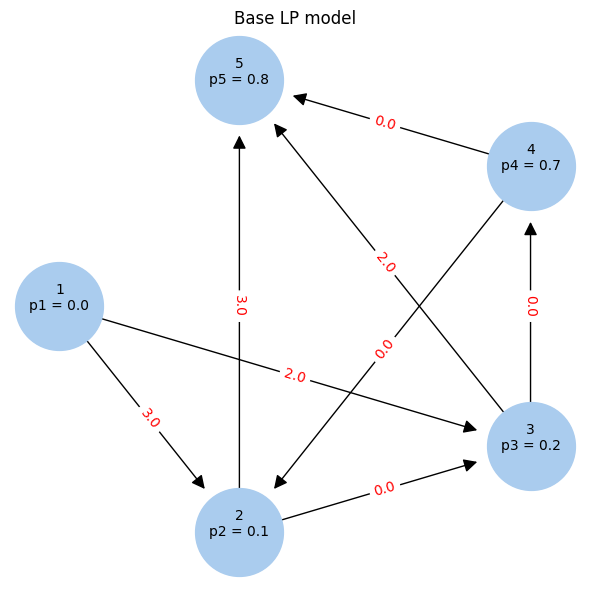

,Solver Status,Model Status,Objective,Num of Equations,Num of Variables,Model Type,Solver,Solver Time
0,Normal,OptimalGlobal,3.628764e-13,13,13,MCP,PATH,0.002


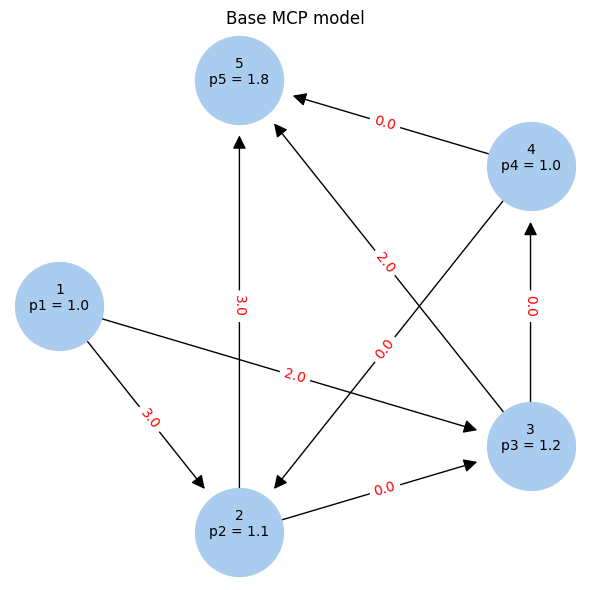

In [45]:
p = gp.Variable(m,type='positive',domain=[j],description='shadow price at demand node j')
x = gp.Variable(m,type='positive',domain=[i,j],description='shipment quantities in cases')
x.up[i,j] = u

obj = gp.Variable(m)
defobj = gp.Equation(m)
defobj[:] = obj == gp.Sum(arcs[i,j], c[i,j]*x[i,j])
# obj = gp.Sum(arcs[i,j], c[i,j]*x[i,j])
conserve = gp.Equation(m,domain=[i],description='balance of flow at i')
conserve[i] =  gp.Sum(arcs[j,i], x[j,i]) + s[i] >= gp.Sum(arcs[i,j], x[i,j]) + d[i]

profit = gp.Equation(m,domain=[i,j],description='zero profit conditions')
profit[arcs[i,j]] = p[i] + c[i,j] >= p[j]

t_opt= gp.Model(m,
    equations=[defobj,conserve],
    problem=gp.Problem.LP,
    sense=gp.Sense.MIN,
    objective=obj,
)

display(t_opt.solve())
G = gamspy_to_digraph_plot(i, arcs, roundVals(conserve.toDict('marginal')), roundVals(x.toDict()), title="Base LP model")

t_mcp= gp.Model(m,
    matches={conserve: p, profit: x},
    problem=gp.Problem.MCP,   
)

# initial estimate:
p.l[j] = 1
# Fix numeraire
p.fx['1'] = 1.
# p.l[i] = conserve.m[i]
display(t_mcp.solve())

#display(x.pivot().round(2),p.l.records.round(2))
Gbase = gamspy_to_digraph_plot(i, arcs, roundVals(p.toDict()), roundVals(x.toDict()), title="Base MCP model")

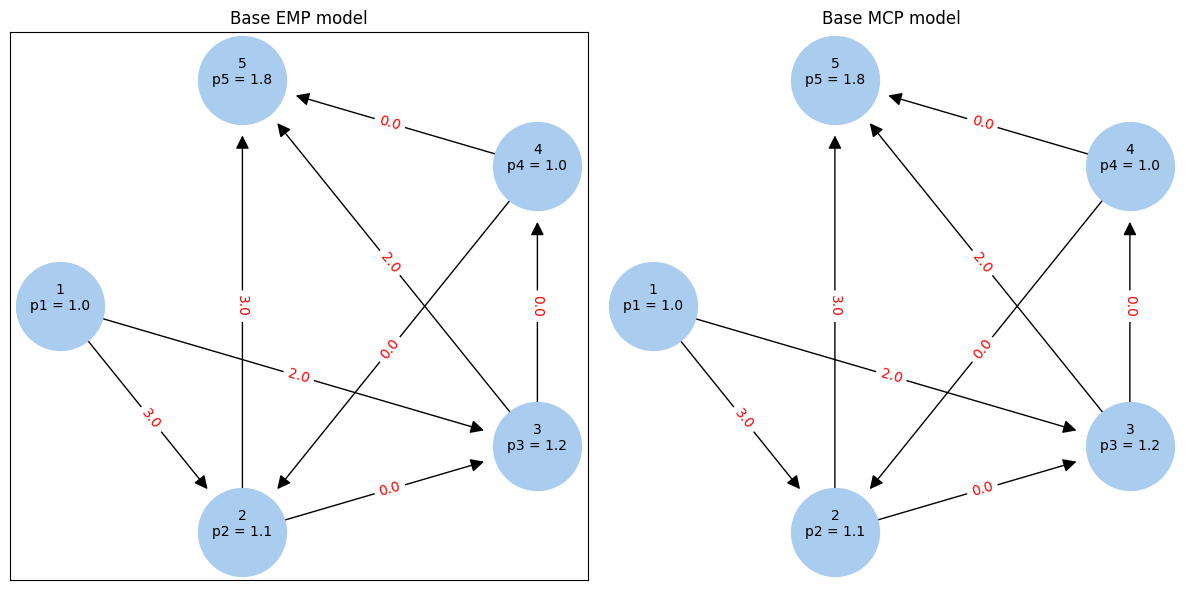

In [46]:
def ReSHOPAnnotation(m, s):
    return m.addGamsCode("EmbeddedCode ReSHOP:\n" + s + "\nendEmbeddedCode")

ReSHOPAnnotation(m,"""
main: min obj x defobj conserve
root: vi main.kkt()
"""
)

t_emp= gp.Model(m,
    equations=[defobj,conserve],
    problem=gp.Problem.EMP,
)

# reset initial values
x.l[i,j] = 0

t_emp.solve(output=None, solver="reshop")
#display(x.pivot().round(2),conserve.m.records.round(2))
Greshop = gamspy_to_digraph_plot(i, arcs, roundVals(p.toDict()), roundVals(x.toDict()), title="Base EMP model", graphs={"Base MCP model": Gbase})

# Now model congestion

$$c(x) = \sum_{i,j} c_{ij}x_{ij}+\beta\left(\dfrac{x_{ij}}{\bar{x}_{ij}}\right)^5 $$

,Solver Status,Model Status,Objective,Num of Equations,Num of Variables,Model Type,Solver,Solver Time
0,Normal,OptimalGlobal,6.443990e-11,13,13,MCP,PATH,0.004


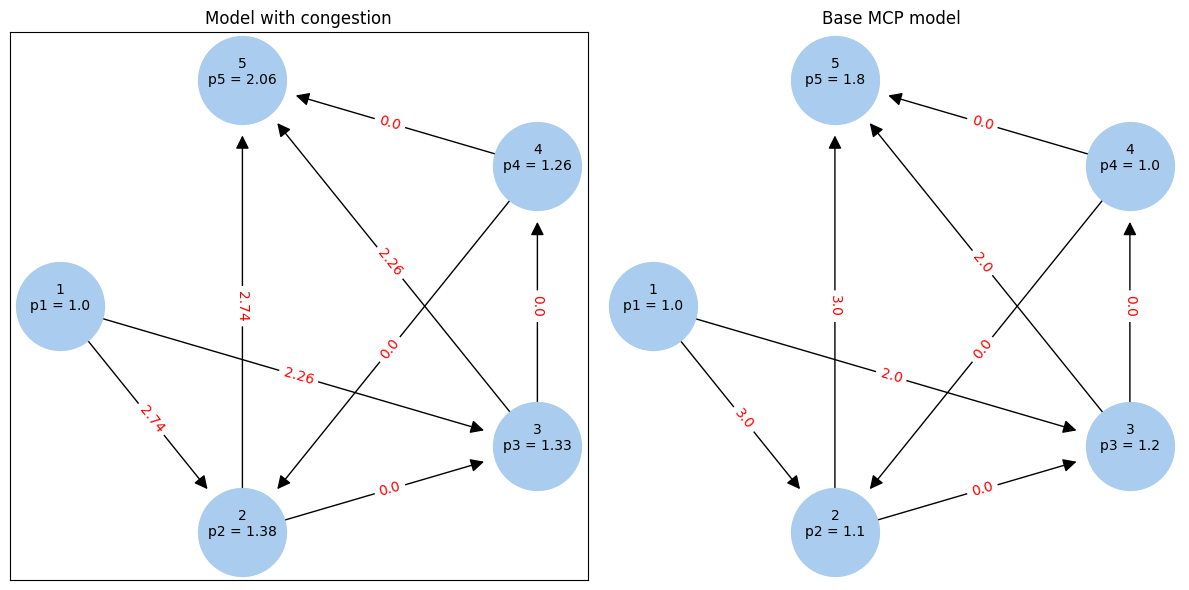

In [47]:
beta = 0.001
rational = gp.Equation(m,domain=[i,j],description='congestion conditions')
rational[arcs[i,j]] = p[i] + c[i,j] + 5*beta*gpm.power(x[i,j],4) >= p[j]
x.up[arcs[i,j]] = gp.SpecialValues.POSINF

t_mcp= gp.Model(m,
    matches={conserve: p, rational: x},
    problem=gp.Problem.MCP,   
)

display(t_mcp.solve())
#display(x.pivot().round(2),p.l.records.round(2))
Gcongestion = gamspy_to_digraph_plot(i, arcs, roundVals(p.toDict()), roundVals(x.toDict()), title="Model with congestion", graphs={"Base MCP model": Gbase})

# Now model nonlinear demand

,Solver Status,Model Status,Objective,Num of Equations,Num of Variables,Model Type,Solver,Solver Time
0,Normal,OptimalGlobal,1.002637e-09,13,13,MCP,PATH,0.005


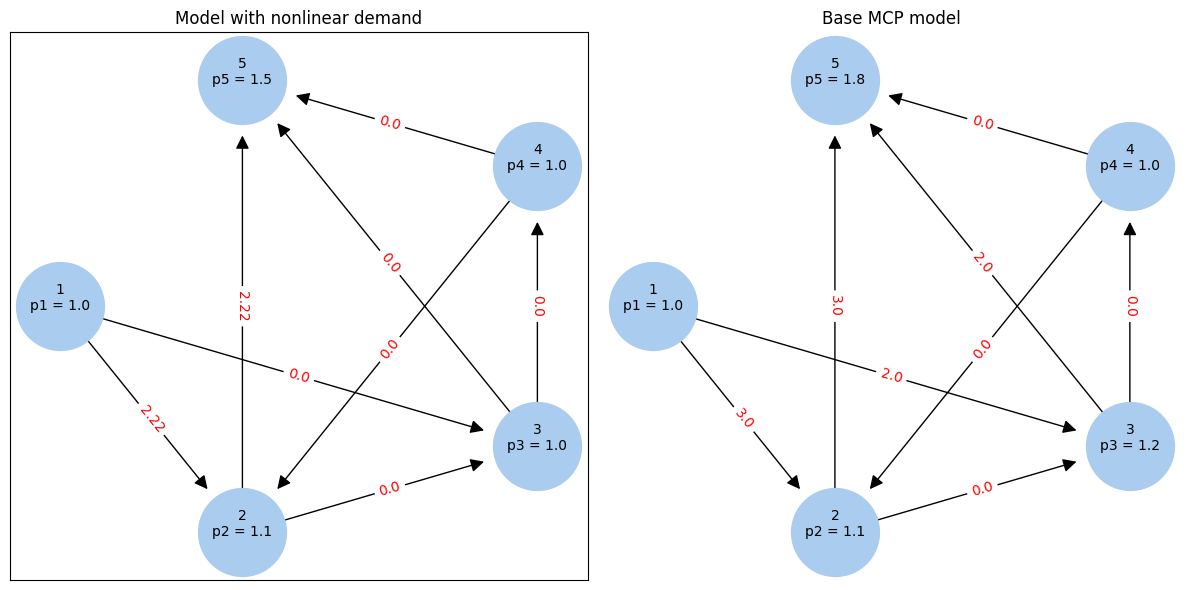

In [48]:
conserve[i] =  gp.Sum(arcs[j,i], x[j,i]) + s[i]*gpm.sqr(p[i]) >= gp.Sum(arcs[i,j], x[i,j]) + (d[i]/gpm.sqr(p[i])).where[d[i]]
rational[arcs[i,j]] = p[i] + c[i,j] >= p[j]
x.up[arcs] = u

# Use starting point since multiple equilibria
x.l[arcs] = 0
p.l[i] = 1

display(t_mcp.solve(output=None))
#display(x.pivot().round(2),p.l.records.round(4))
G = gamspy_to_digraph_plot(i, arcs, roundVals(p.toDict()), roundVals(x.toDict()), title="Model with nonlinear demand", graphs={"Base MCP model": Gbase})

# Now model exogenous taxes

,Solver Status,Model Status,Objective,Num of Equations,Num of Variables,Model Type,Solver,Solver Time
0,Normal,OptimalGlobal,9.237056e-14,13,13,MCP,PATH,0.002


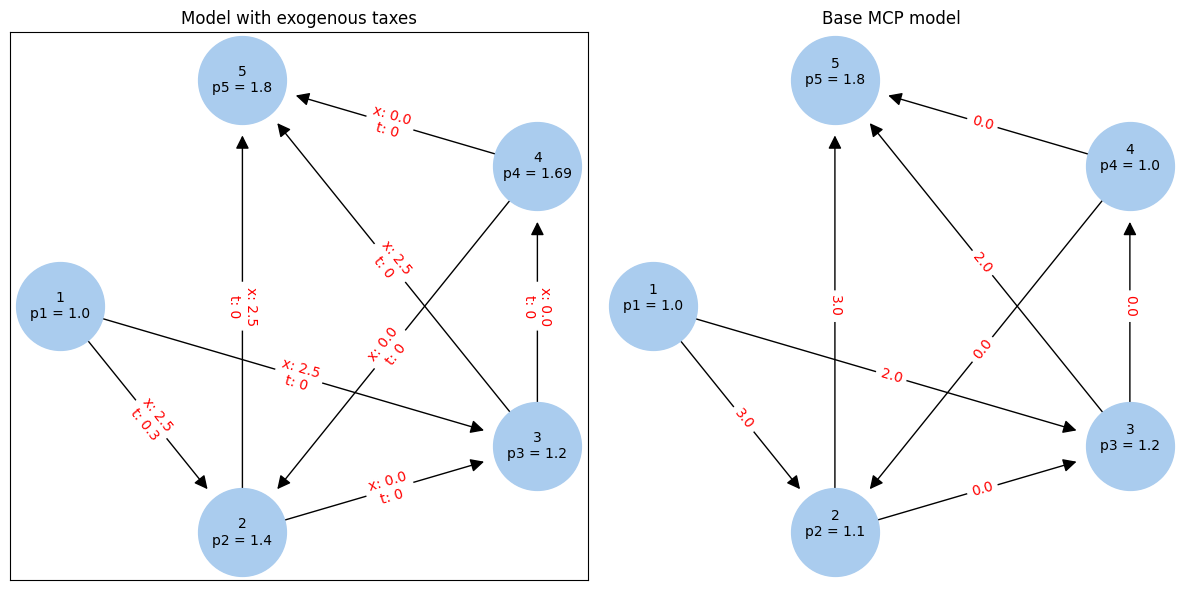

In [49]:
ex = gp.Parameter(m,domain=[i,j],description='export tax',records=[('1', '2', 0.3)])
im = gp.Parameter(m,domain=[i,j],description='import tax',records=[('1','2',0.0)])

rational[arcs[i,j]] = (1+ex[i,j])*(1+im[i,j])*p[i] + c[i,j] >= p[j]
conserve[i] =  gp.Sum(arcs[j,i], x[j,i]) + s[i] >= gp.Sum(arcs[i,j], x[i,j]) + d[i]

# Use starting point since multiple equilibria
x.l[arcs] = 0
p.l[i] = 1

display(t_mcp.solve(output=None))
#display(x.pivot().round(2),p.l.records.round(2))
nodeVals = OrderedDict({"p":  roundVals(p.toDict())})
arcVals = OrderedDict({"x": roundVals(x.toDict()), "t": roundVals(ex.toDict())})
Gexog = gamspy_to_digraph_plot(i, arcs, nodeVals, arcVals, title="Model with exogenous taxes", graphs={"Base MCP model": Gbase})

# Now model progressive taxes

$$t_{ij} = \bar{t}_{ij} +\gamma_{ij} p_i x_{ij} $$

,Solver Status,Model Status,Objective,Num of Equations,Num of Variables,Model Type,Solver,Solver Time
0,Normal,OptimalGlobal,3.137921e-07,21,21,MCP,PATH,0.009


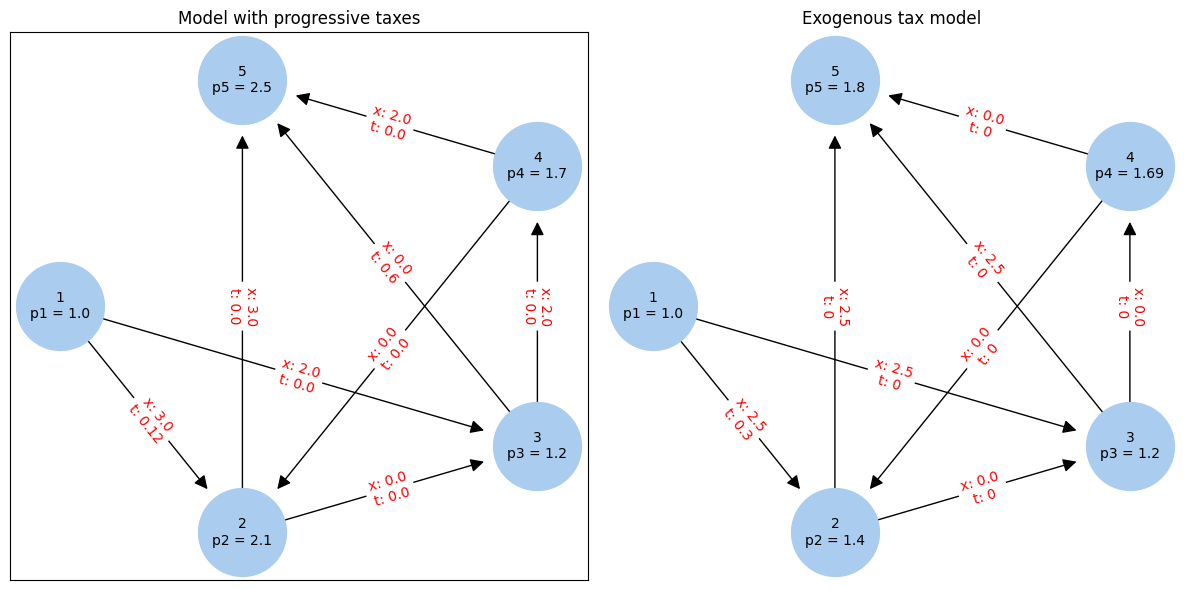

In [50]:
tbar = gp.Parameter(m,domain=[i,j],records=[('1', '2', 0.1),('3', '5', 0.6)])
gamma = gp.Parameter(m,domain=[i,j])
gamma[i,j] = 0.1

t = gp.Variable(m,domain=[i,j])
t.up[i,j] = 1.2*gpm.Max(0,tbar[i,j])
t.lo[i,j] = 1.2*gpm.Min(0,tbar[i,j])

rational[arcs[i,j]] = (1+t[i,j])*p[i] + c[i,j] >= p[j]

tax = gp.Equation(m,domain=[i,j])
tax[i,j].where[arcs[i,j]] = t[i,j] == tbar[i,j] + gamma[i,j]*p[i]*x[i,j]
  
tax_cp= gp.Model(m,
    matches={conserve: p, rational: x, tax: t},
    problem=gp.Problem.MCP,   
)

# Use starting point since multiple equilibria
x.l[arcs] = 0
p.l[i] = 0

display(tax_cp.solve(output=None))
#display(x.pivot().round(2),p.l.records.round(2),t.l.records.round(3))
nodeVals = OrderedDict({"p":  roundVals(p.toDict())})
arcVals = OrderedDict({"x": roundVals(x.toDict()), "t": roundVals(t.toDict())})
G = gamspy_to_digraph_plot(i, arcs, nodeVals, arcVals, title="Model with progressive taxes", graphs={"Exogenous tax model": Gexog})

# Model taxes as MPEC

Who collects the tax revenue?

,Solver Status,Model Status,Objective,Num of Equations,Num of Variables,Model Type,Solver,Solver Time
0,Normal,OptimalLocal,0.36,14,22,MPEC,NLPEC,0.005


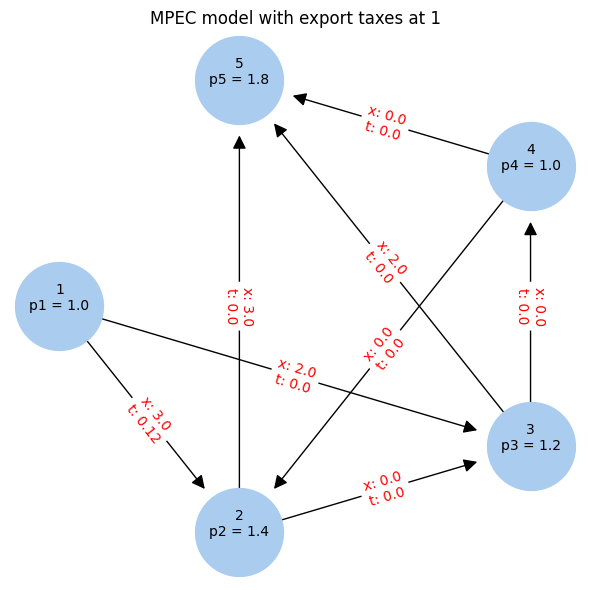

In [51]:
totrev = gp.Sum(arcs[i,j].where[i.sameAs('1')], t[i,j]*p[i]*x[i,j])

tax_mpec = gp.Model(m,
    equations = [],
    matches={conserve: p, rational: x},
    problem=gp.Problem.MPEC,
    sense=gp.Sense.MAX,
    objective=totrev,
)

t.up[i,j] = 1.2*gpm.Max(0,tbar[i,j])
t.lo[i,j] = 1.2*gpm.Min(0,tbar[i,j])

# intialize values
p.l[i] = 1
x.l[i,j] = 0
t.l[i,j] = tbar[i,j]

display(tax_mpec.solve(output=None,options=gp.Options(mpec='nlpec',dnlp='conopt')))

arcVals = OrderedDict({"x": roundVals(x.toDict()), "t": roundVals(t.toDict())})
Gmpec1 = gamspy_to_digraph_plot(i, arcs, roundVals(p.toDict()), arcVals, title="MPEC model with export taxes at 1")



,Solver Status,Model Status,Objective,Num of Equations,Num of Variables,Model Type,Solver,Solver Time
0,Normal,OptimalLocal,1.4,14,22,MPEC,NLPEC,0.005


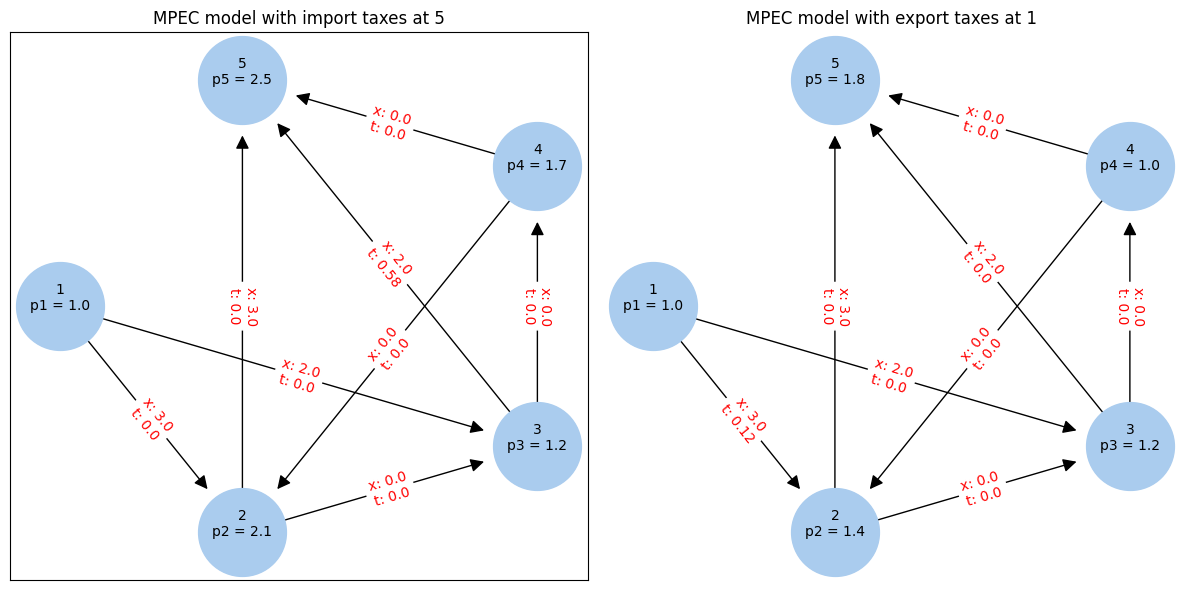

In [52]:
totrev = gp.Sum(arcs[i,j].where[j.sameAs('5')], t[i,j]*p[i]*x[i,j])

tax_mpec = gp.Model(m,
    equations = [],
    matches={conserve: p, rational: x},
    problem=gp.Problem.MPEC,
    sense=gp.Sense.MAX,
    objective=totrev,
)

# intialize values
p.l[i] = 1
x.l[i,j] = 0
t.l[i,j] = tbar[i,j]

display(tax_mpec.solve(output=None,options=gp.Options(mpec='nlpec',dnlp='conopt')))

#display(x.pivot().round(2),p.l.records.round(2),t.l.records.round(3))
arcVals = OrderedDict({"x": roundVals(x.toDict()), "t": roundVals(t.toDict())})
Gmpec5 = gamspy_to_digraph_plot(i, arcs, roundVals(p.toDict()), arcVals, title="MPEC model with import taxes at 5", graphs={"MPEC model with export taxes at 1": Gmpec1})

# Model competition

--- Job _jrgpRZTtSNajkI72WqAN0g.gms Start 12/09/25 15:41:28 51.2.1 5fb43f63 DAX-DAC arm 64bit/macOS
--- Applying:
    /Users/ferris/.venvs/gamspy/lib/python3.13/site-packages/gamspy_base/gmsprmun.txt
    /Users/ferris/Library/Preferences/GAMS/gamsconfig.yaml
--- GAMS Parameters defined
    EMP reshop
    Input /var/folders/yz/_rxq7zs56y5cnkx3mcnkr7txvxb3pw/T/tmpwoz_x9pw/_jrgpRZTtSNajkI72WqAN0g.gms
    Output /var/folders/yz/_rxq7zs56y5cnkx3mcnkr7txvxb3pw/T/tmpwoz_x9pw/_jrgpRZTtSNajkI72WqAN0g.lst
    ScrDir /var/folders/yz/_rxq7zs56y5cnkx3mcnkr7txvxb3pw/T/tmpwoz_x9pw/tmpiw7fz9xm/
    SysDir /Users/ferris/.venvs/gamspy/lib/python3.13/site-packages/gamspy_base/
    LogOption 3
    Trace /var/folders/yz/_rxq7zs56y5cnkx3mcnkr7txvxb3pw/T/tmpwoz_x9pw/_jrgpRZTtSNajkI72WqAN0g.txt
    License "/Users/ferris/Library/Application Support/GAMSPy/gamspy_license.txt"
    OptFile 0
    OptDir /var/folders/yz/_rxq7zs56y5cnkx3mcnkr7txvxb3pw/T/tmpwoz_x9pw/
    LimRow 0
    LimCol 0
    TraceOpt 3
    GDX 

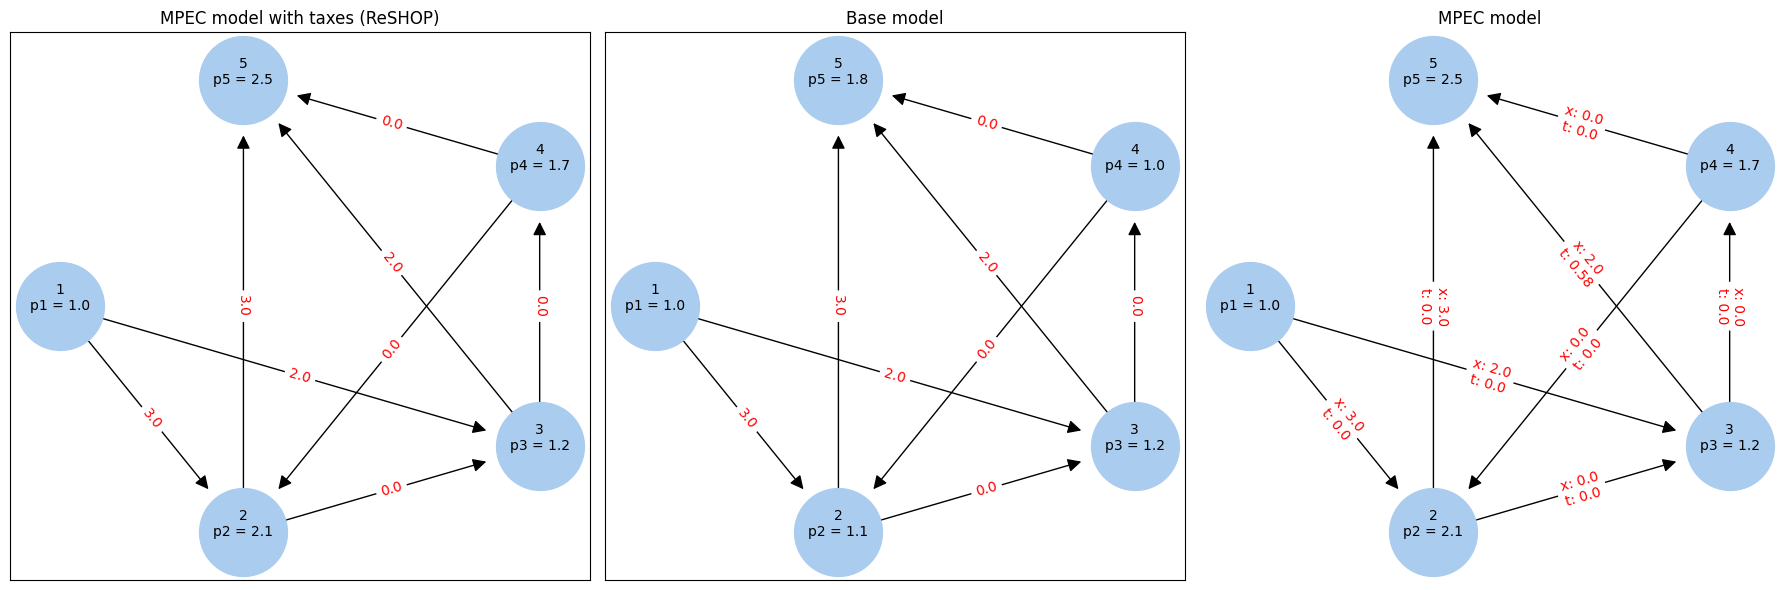

--- Returning from GAMS NLPEC step

--- Additional Mpec Equations = 20
--- Additional Mpec Variables = 20
--- Reading solution for model t_emp
--- Executing after solve: elapsed 0:00:00.067
--- _jrgpRZTtSNajkI72WqAN0g.gms(1214) 4 Mb
--- GDX File /var/folders/yz/_rxq7zs56y5cnkx3mcnkr7txvxb3pw/T/tmpwoz_x9pw/_jrgpRZTtSNajkI72WqAN0gout.gdx
*** Status: Normal completion
--- Job _jrgpRZTtSNajkI72WqAN0g.gms Stop 12/09/25 15:41:28 elapsed 0:00:00.067


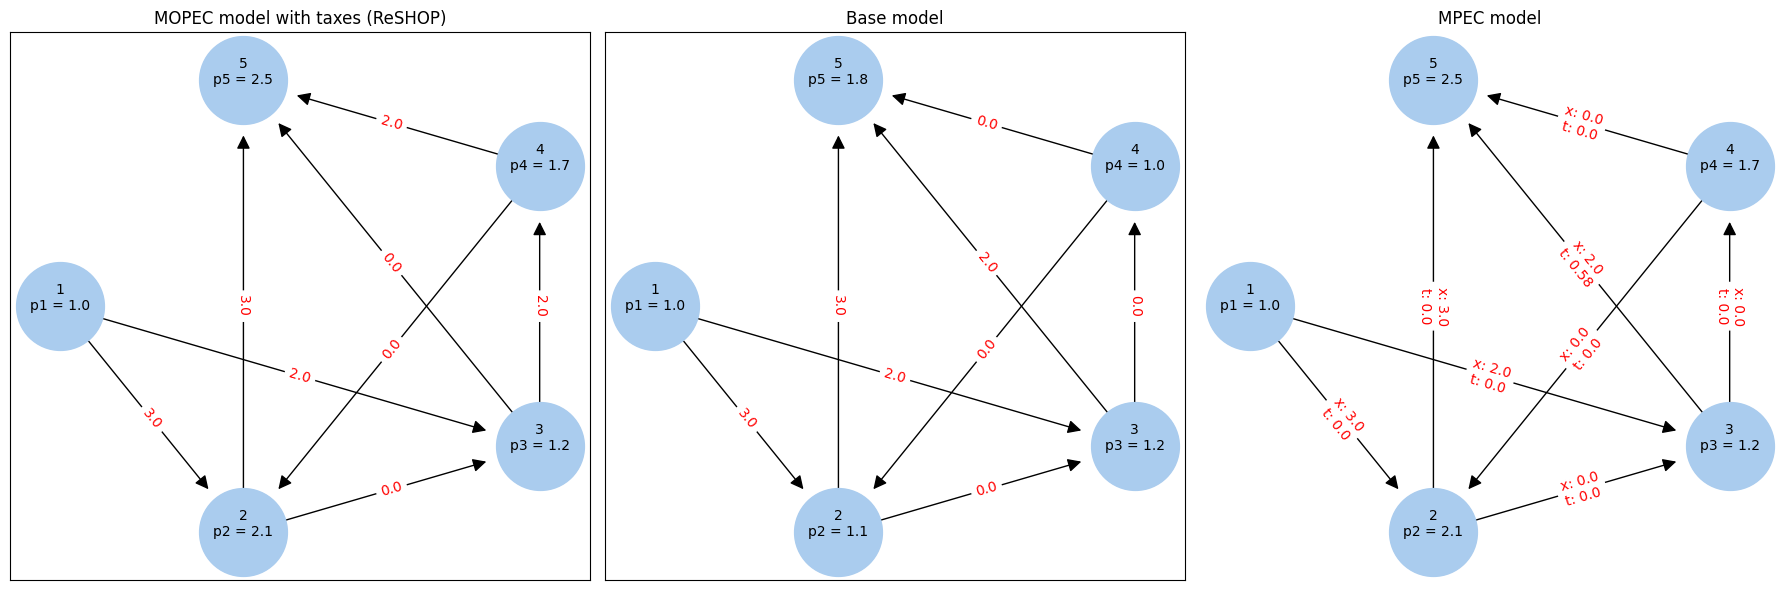

In [ ]:
def ReSHOPAnnotation(m, s):
    return m.addGamsCode("EmbeddedCode ReSHOP:\n" + s + "\nendEmbeddedCode")

taxRevenue = gp.Variable(m)
defTaxRevenue = gp.Equation(m)

defTaxRevenue[:] = taxRevenue == gp.Sum(arcs[i,j], t[i,j]*p[i]*x[i,j])

ReSHOPAnnotation(m,"""
taxrev: max taxRevenue t defTaxRevenue transport_kkt
transport_kkt: vi conserve p rational x
"""
)

t_emp = gp.Model(m,
    equations=[conserve,defTaxRevenue,rational],
    problem=gp.Problem.EMP,
)

t_emp.solve(output=sys.stdout, solver="reshop")
Gmpec_rhp = gamspy_to_digraph_plot(i, arcs, roundVals(p.toDict()), roundVals(x.toDict()), title="MPEC model with taxes (ReSHOP)", graphs={"Base model": Gbase, "MPEC model": Gmpec5})

# Following is different setup - MOPEC not MPEC
ReSHOPAnnotation(m,"""
taxrev: max taxRevenue t defTaxRevenue
transport_kkt: vi conserve p rational x
root: Nash(taxrev, transport_kkt)
"""
)

t_emp = gp.Model(m,
    equations=[conserve,defTaxRevenue,rational],
    problem=gp.Problem.EMP,
)

t_emp.solve(output=sys.stdout, solver="reshop")
GNash_rhp = gamspy_to_digraph_plot(i, arcs, roundVals(p.toDict()), roundVals(x.toDict()), title="MOPEC model with taxes (ReSHOP)", graphs={"Base model": Gbase, "MPEC model": Gmpec5})